In [11]:
!pip freeze | grep matplotlib

matplotlib==3.8.0
matplotlib-inline==0.1.6


In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def plot(imgs, titles=None, figsize=None):
    if not isinstance(imgs, (list, tuple)):
        imgs = [imgs]

    n = len(imgs)
    
    if not figsize:
        figsize = (5 * n, 5)
    fig, axes = plt.subplots(1, n, figsize=figsize)

    if n == 1:
        axes = [axes]

    if titles is None:
        titles = [None] * n

    for ax, img, title in zip(axes, imgs, titles):
        # Convert OpenCV BGR -> RGB
        if img.ndim == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        ax.imshow(img, cmap="gray" if img.ndim == 2 else None)

        if title is not None:
            ax.set_title(title)

        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [27]:
from pathlib import Path
import random
import cv2

image_dir = Path("logs/msa_test_stare_aug_2026_06_29_04_40_09/Samples")
image_paths = [str(image_path) for image_path in image_dir.rglob("*.jpg")]
len(image_paths), image_paths[0]

(903,
 'logs/msa_test_stare_aug_2026_06_29_04_40_09/Samples/TrainrandomGaussian1im0002+randomRotation1im0236+epoch+52.jpg')

Each column, from top to bottom, image -> prediction -> mask


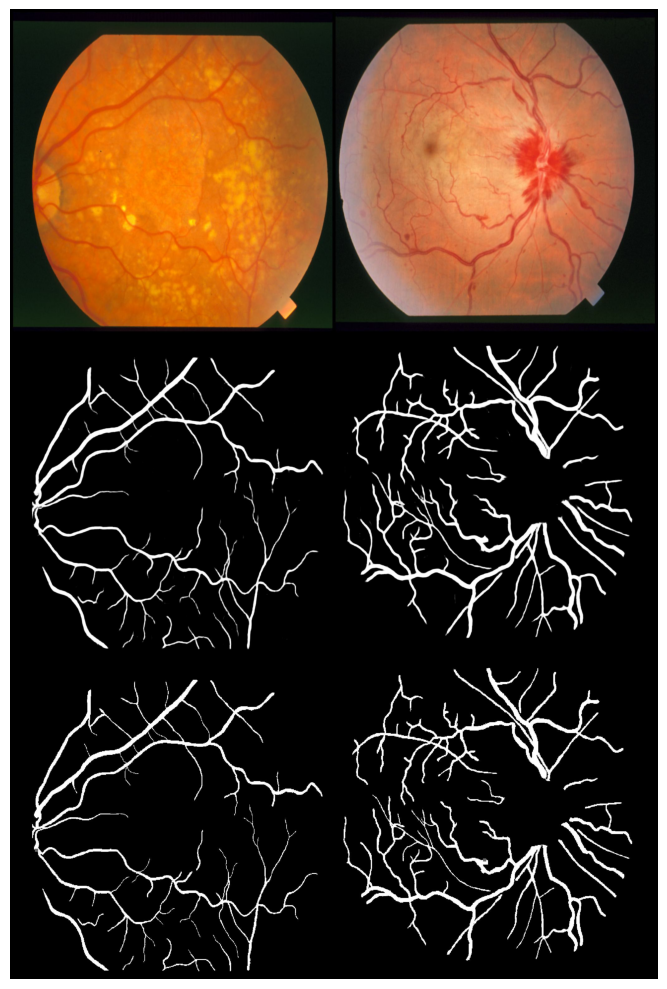

In [29]:
print("Each column, from top to bottom, image -> prediction -> mask") 
random_indices = random.sample(range(len(image_paths)), 1)
images = [cv2.imread(image_paths[index]) for index in random_indices]
plot(images, figsize=(30, 10))